In [1]:
import importlib.util
import subprocess
import sys

dependencies = {
    "pandas": "pandas>=2.2,<4",
    "numpy": "numpy>=1.26,<3",
    "matplotlib": "matplotlib>=3.9,<4",
    "seaborn": "seaborn>=0.13,<0.14",
    "missingno": "missingno==0.5.2",
    "IPython": "ipython>=8,<10",
}
missing_packages = [requirement for module, requirement in dependencies.items()
                    if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--root-user-action=ignore", *missing_packages])

import json
from pathlib import Path
from urllib.request import urlopen
import pandas as pd
import numpy as np
import matplotlib
from IPython import get_ipython
from IPython.display import display, Markdown

if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")
else:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import missingno

pd.set_option("display.max_columns", 26)
pd.set_option("display.max_rows", 30)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

OUTPUT_DIR = Path("hasil")
FIGURE_DIR = OUTPUT_DIR / "grafik"
TABLE_DIR = OUTPUT_DIR / "tabel"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename):
    fig.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches="tight", facecolor="white")
    if get_ipython() is not None:
        plt.show()
    plt.close(fig)


In [2]:
DATA_PATH = Path("Automobile_data.csv")
DATA_URL = (
    "https://raw.githubusercontent.com/rushabh-mehta/EDA-on-Automobile-Dataset/"
    "5754646cab131214665a6bcf82e27869edbd120c/Automobile_data.csv"
)

if not DATA_PATH.is_file():
    with urlopen(DATA_URL, timeout=30) as response:
        DATA_PATH.write_bytes(response.read())

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
assert df.shape == (205, 26)
print(f"Ukuran data: {df.shape[0]} baris x {df.shape[1]} kolom")
display(df.head())


Ukuran data: 205 baris x 26 kolom


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


# 1. Missing value

Tanda `?` diubah menjadi `NaN`. Nilai kosong pada kolom numerik diisi dengan mean, sedangkan `num-of-doors` diisi dengan modus.


In [3]:
display(df.isnull().any().to_frame("terdeteksi_null_sebelum_konversi"))
print("Jumlah penanda '?' yang belum dianggap null:", int(df.eq("?").sum().sum()))


,terdeteksi_null_sebelum_konversi
symboling,False
normalized-losses,False
make,False
fuel-type,False
aspiration,False
num-of-doors,False
body-style,False
drive-wheels,False
engine-location,False
wheel-base,False


Jumlah penanda '?' yang belum dianggap null: 59


In [4]:
df = df.replace("?", np.nan)
missing_before = df.isnull().sum()
expected_missing = {"normalized-losses": 41, "num-of-doors": 2, "bore": 4,
                    "stroke": 4, "horsepower": 2, "peak-rpm": 2, "price": 4}
assert missing_before[missing_before > 0].to_dict() == expected_missing
display(missing_before.to_frame("missing_sebelum_imputasi"))
print("Total missing value:", int(missing_before.sum()))


,missing_sebelum_imputasi
symboling,0
normalized-losses,41
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


Total missing value: 59


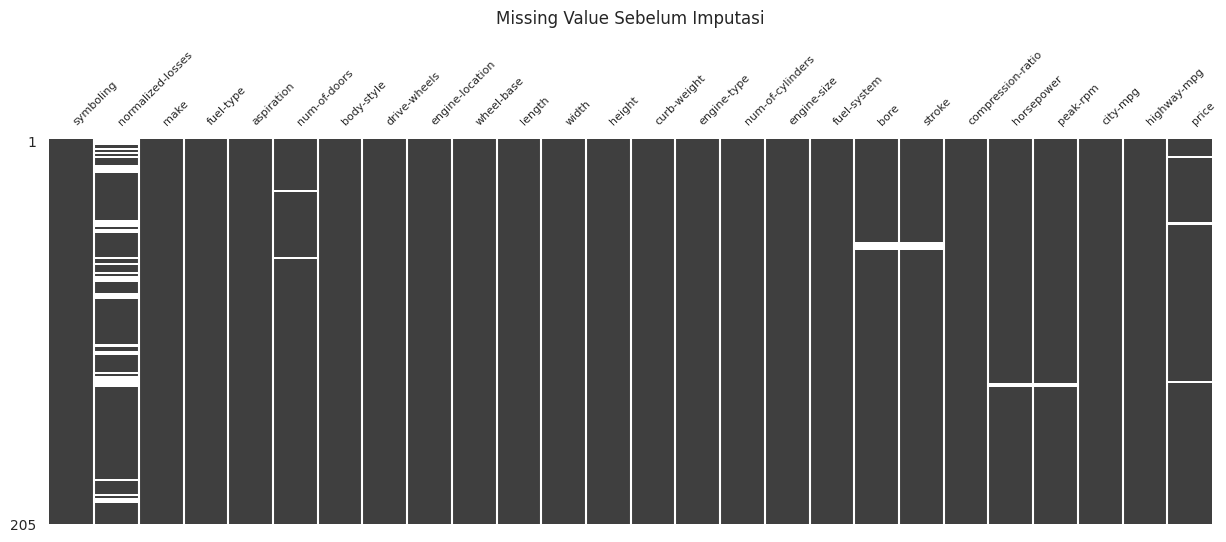

In [5]:
ax = missingno.matrix(df, figsize=(15, 5), fontsize=8, sparkline=False)
ax.set_title("Missing Value Sebelum Imputasi", pad=18)
save_figure(ax.get_figure(), "01_missing_sebelum.png")


In [6]:
numerical_cols_to_fill = ["normalized-losses", "bore", "stroke",
                          "horsepower", "peak-rpm", "price"]
imputation_records = []
for col in numerical_cols_to_fill:

    df[col] = pd.to_numeric(df[col], errors="raise").astype(float)
    mean_val = df[col].mean()
    if pd.isna(mean_val):
        raise ValueError(f"Mean tidak dapat dihitung untuk kolom {col}.")
    imputation_records.append({"kolom": col, "metode": "mean",
                               "nilai_pengisi": mean_val,
                               "jumlah_diisi": int(df[col].isna().sum())})
    df[col] = df[col].fillna(mean_val)

mode_val = df["num-of-doors"].mode().iloc[0]
imputation_records.append({"kolom": "num-of-doors", "metode": "modus",
                           "nilai_pengisi": mode_val,
                           "jumlah_diisi": int(df["num-of-doors"].isna().sum())})
df["num-of-doors"] = df["num-of-doors"].fillna(mode_val)
imputation_summary = pd.DataFrame(imputation_records)
missing_after = df.isnull().sum()
missing_summary = pd.DataFrame({"sebelum": missing_before, "sesudah": missing_after})
assert missing_after.sum() == 0, "Masih terdapat missing value setelah imputasi."
assert df.shape == df_raw.shape, "Imputasi tidak boleh menghapus baris atau kolom."
df_imputed = df.copy()
display(imputation_summary)
display(missing_summary.loc[missing_summary["sebelum"] > 0])
display(df.head())
print("Total missing value sesudah imputasi:", int(missing_after.sum()))


,kolom,metode,nilai_pengisi,jumlah_diisi
0,normalized-losses,mean,122.0,41
1,bore,mean,3.3298,4
2,stroke,mean,3.2554,4
3,horsepower,mean,104.2562,2
4,peak-rpm,mean,5125.3695,2
5,price,mean,13207.1294,4
6,num-of-doors,modus,four,2


,sebelum,sesudah
normalized-losses,41,0
num-of-doors,2,0
bore,4,0
stroke,4,0
horsepower,2,0
peak-rpm,2,0
price,4,0


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


Total missing value sesudah imputasi: 0


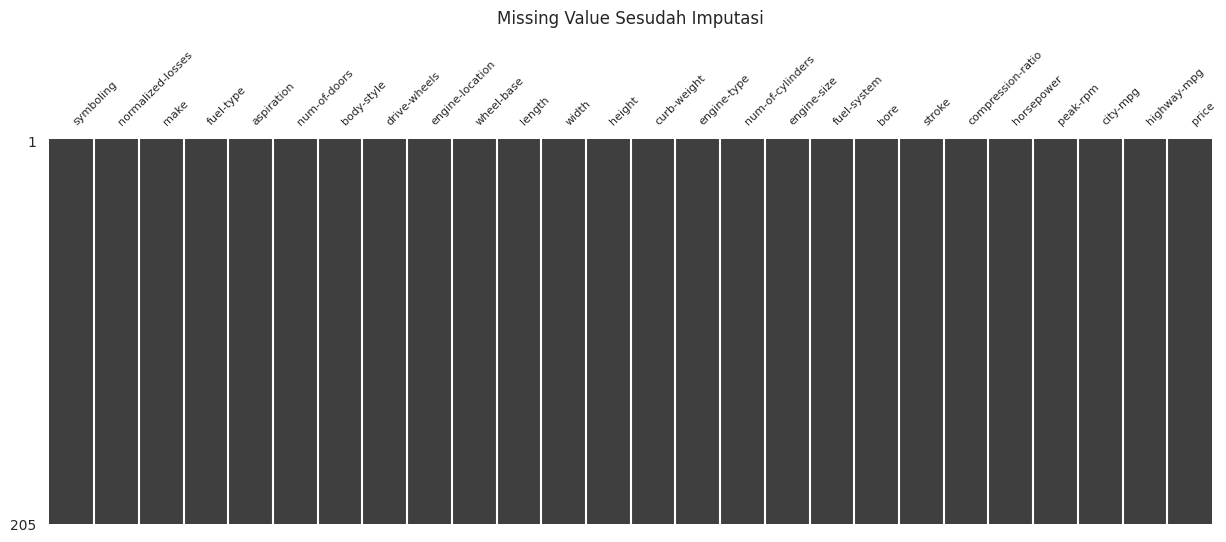

In [7]:
ax = missingno.matrix(df, figsize=(15, 5), fontsize=8, sparkline=False)
ax.set_title("Missing Value Sesudah Imputasi", pad=18)
save_figure(ax.get_figure(), "02_missing_sesudah.png")


# 2. Outlier

## A. Outlier harga

Batas IQR: `Q1 - 1.5 × IQR` sampai `Q3 + 1.5 × IQR`.


In [8]:
Q1 = round(float(df["price"].quantile(0.25)), 12)
Q3 = round(float(df["price"].quantile(0.75)), 12)
IQR = round(Q3 - Q1, 12)
lower_bound = round(Q1 - 1.5 * IQR, 12)
upper_bound = round(Q3 + 1.5 * IQR, 12)
outliers = df.loc[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"Price: Q1={Q1:.2f}; Q3={Q3:.2f}; IQR={IQR:.2f}")
print(f"Batas bawah={lower_bound:.2f}; batas atas={upper_bound:.2f}")
print("Jumlah outlier price sebelum clamping:", len(outliers))
display(outliers[["make", "body-style", "price"]])


Price: Q1=7788.00; Q3=16500.00; IQR=8712.00
Batas bawah=-5280.00; batas atas=29568.00
Jumlah outlier price sebelum clamping: 14


,make,body-style,price
15,bmw,sedan,30760.0
16,bmw,sedan,41315.0
17,bmw,sedan,36880.0
47,jaguar,sedan,32250.0
48,jaguar,sedan,35550.0
49,jaguar,sedan,36000.0
70,mercedes-benz,sedan,31600.0
71,mercedes-benz,sedan,34184.0
72,mercedes-benz,convertible,35056.0
73,mercedes-benz,sedan,40960.0


Terdapat 14 harga di atas batas IQR. Harga yang tinggi dapat berasal dari mobil mewah, sehingga outlier belum tentu merupakan kesalahan data.


## B. Clamping


### Outlier pada kolom numerik


In [9]:
def count_outliers(series, lower, upper):
    return int(((series < lower) | (series > upper)).sum())

numeric_cols = df.select_dtypes(include="number").columns.tolist()
df_before = df.copy()
outlier_records = []
for col in numeric_cols:
    q1 = round(float(df_before[col].quantile(0.25)), 12)
    q3 = round(float(df_before[col].quantile(0.75)), 12)
    iqr = round(q3 - q1, 12)

    lower = round(q1 - 1.5 * iqr, 12)
    upper = round(q3 + 1.5 * iqr, 12)
    before_count = count_outliers(df_before[col], lower, upper)
    df[col] = df_before[col].astype(float).clip(lower=lower, upper=upper)

    after_count = count_outliers(df[col], lower, upper)
    outlier_records.append({"kolom": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                            "batas_bawah": lower, "batas_atas": upper,
                            "outlier_sebelum": before_count, "outlier_sesudah": after_count,
                            "nilai_diubah": int((df[col] != df_before[col]).sum())})

outlier_summary = pd.DataFrame(outlier_records).set_index("kolom")
assert outlier_summary["outlier_sesudah"].sum() == 0
assert df.shape == df_before.shape
assert df.isna().sum().sum() == 0
display(outlier_summary.round(4))


,Q1,Q3,IQR,batas_bawah,batas_atas,outlier_sebelum,outlier_sesudah,nilai_diubah
kolom,,,,,,,,
symboling,0.00,2.00,2.00,-3.000,5.000,0,0,0
normalized-losses,101.00,137.00,36.00,47.000,191.000,8,0,8
wheel-base,94.50,102.40,7.90,82.650,114.250,3,0,3
length,166.30,183.10,16.80,141.100,208.300,0,0,0
width,64.10,66.90,2.80,59.900,71.100,8,0,8
height,52.00,55.50,3.50,46.750,60.750,0,0,0
curb-weight,2145.00,2935.00,790.00,960.000,4120.000,0,0,0
engine-size,97.00,141.00,44.00,31.000,207.000,10,0,10
bore,3.15,3.58,0.43,2.505,4.225,0,0,0


Nilai di luar batas IQR dibatasi menggunakan `clip`. Jumlah baris tetap sama.


## C. Boxplot harga dan horsepower


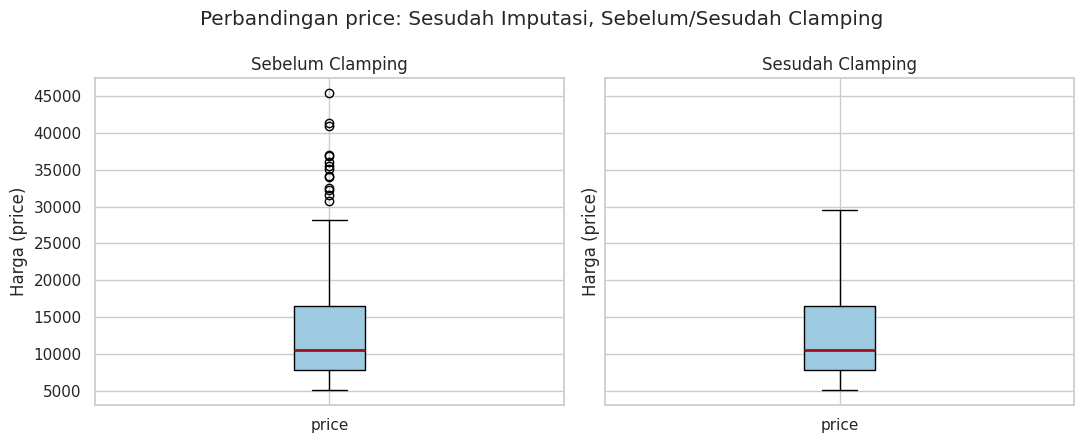

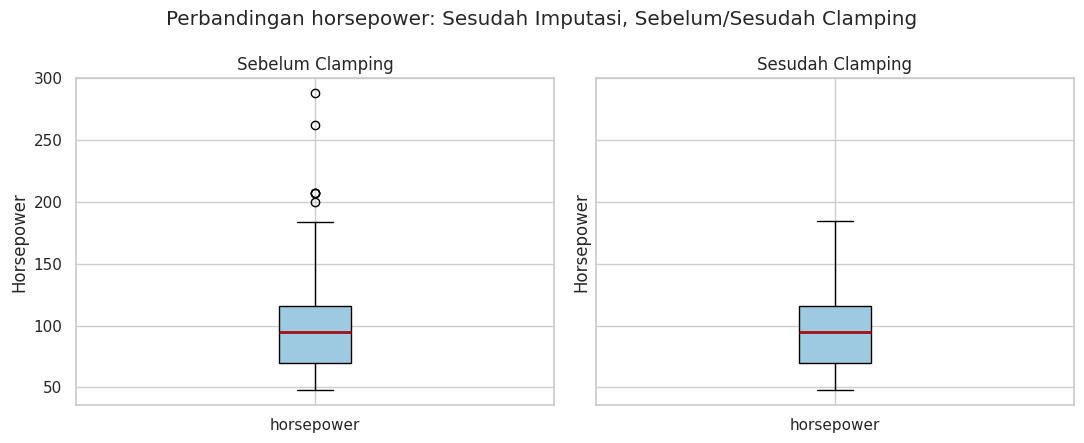

In [10]:
for feature in ["price", "horsepower"]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
    for ax, values, title in zip(
        axes, [df_before[feature], df[feature]], ["Sebelum Clamping", "Sesudah Clamping"]
    ):
        ax.boxplot(values.to_numpy(), patch_artist=True,
                   boxprops={"facecolor": "#9ecae1"},
                   medianprops={"color": "#a50f15", "linewidth": 2})
        ax.set_title(title)
        ax.set_xticks([1], [feature])
        ax.set_ylabel("Harga (price)" if feature == "price" else "Horsepower")
    fig.suptitle(f"Perbandingan {feature}: Sesudah Imputasi, Sebelum/Sesudah Clamping")
    fig.tight_layout()
    save_figure(fig, f"03_boxplot_{feature}.png")


# 3. Pivot table


## A. Rata-rata harga menurut merek dan bentuk bodi


In [11]:
pivot_price = pd.pivot_table(df, values="price", index="make",
                            columns="body-style", aggfunc="mean", sort=True)
print("Rata-rata Harga menurut Merek dan Bentuk Bodi (Sesudah Clamping):")
display(pivot_price.round(2))


Rata-rata Harga menurut Merek dan Bentuk Bodi (Sesudah Clamping):


body-style,convertible,hardtop,hatchback,sedan,wagon
make,,,,,
alfa-romero,14997.5,NaN,16500.00,NaN,NaN
audi,NaN,NaN,13207.13,17647.00,18920.00
bmw,NaN,NaN,NaN,23587.38,NaN
chevrolet,NaN,NaN,5723.00,6575.00,NaN
dodge,NaN,NaN,7819.80,7619.67,8921.00
honda,NaN,NaN,7054.43,9945.00,7295.00
isuzu,NaN,NaN,11048.00,11066.42,NaN
jaguar,NaN,NaN,NaN,29568.00,NaN
mazda,NaN,NaN,10085.00,11464.14,NaN


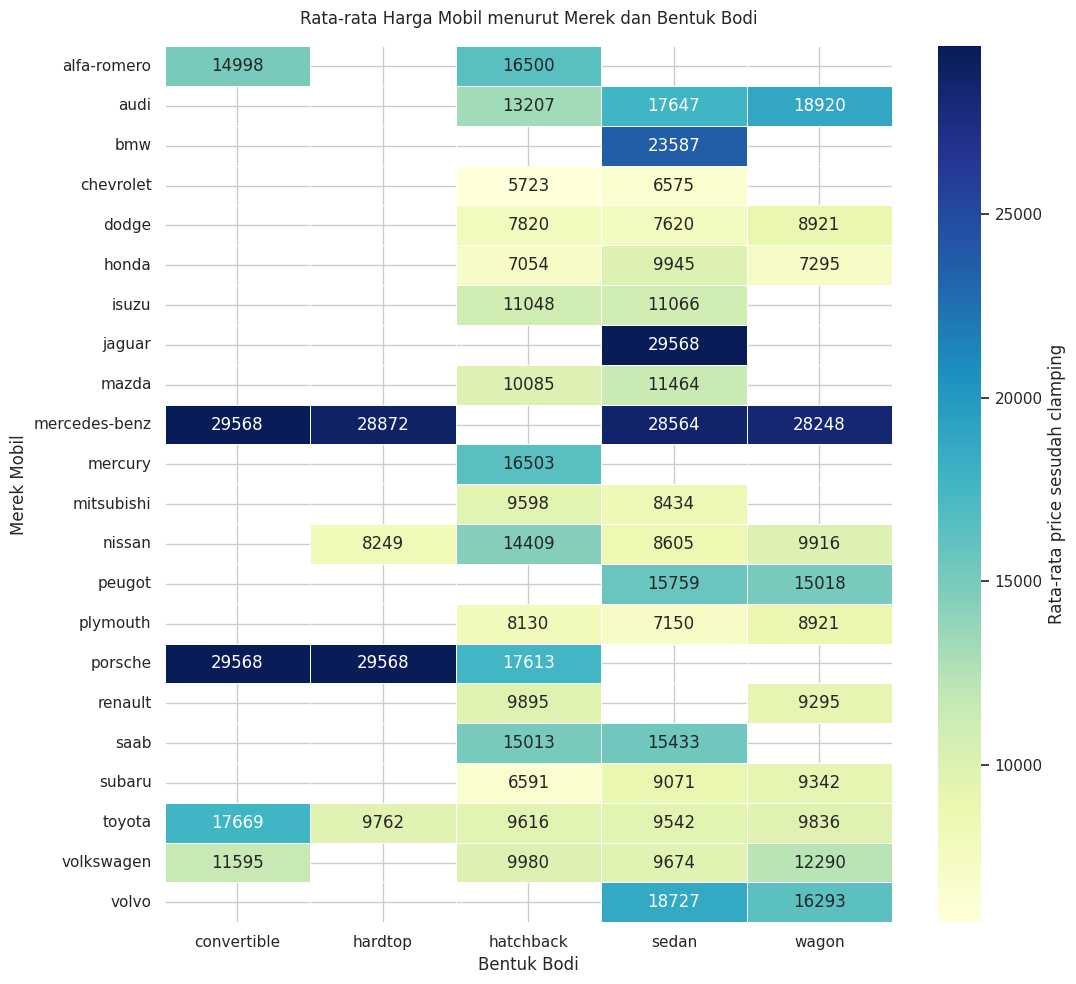

In [12]:
fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(pivot_price, mask=pivot_price.isna(), annot=True, fmt=".0f",
            cmap="YlGnBu", linewidths=0.5,
            cbar_kws={"label": "Rata-rata price sesudah clamping"}, ax=ax)
ax.set_title("Rata-rata Harga Mobil menurut Merek dan Bentuk Bodi", pad=16)
ax.set_xlabel("Bentuk Bodi")
ax.set_ylabel("Merek Mobil")
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
save_figure(fig, "04_heatmap_harga.png")


Pivot menggunakan harga setelah clamping. Sel kosong menunjukkan kombinasi merek dan bodi yang tidak ada dalam data.


## B. Rata-rata horsepower menurut bahan bakar dan aspiration


In [13]:
pivot_hp = pd.pivot_table(df, values="horsepower", index="fuel-type",
                         columns="aspiration", aggfunc="mean", sort=True)
print("Rata-rata Horsepower menurut Bahan Bakar dan Aspiration (Sesudah Clamping):")
display(pivot_hp.round(2))


Rata-rata Horsepower menurut Bahan Bakar dan Aspiration (Sesudah Clamping):


aspiration,std,turbo
fuel-type,,
diesel,58.14,98.62
gas,100.10,137.79


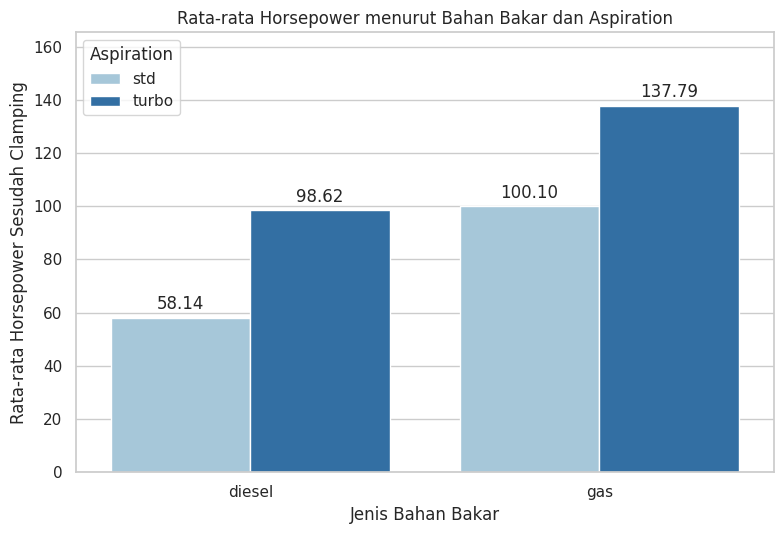

In [14]:
hp_long = pivot_hp.reset_index().melt(id_vars="fuel-type", var_name="aspiration",
                                     value_name="horsepower")
fig, ax = plt.subplots(figsize=(8, 5.5))

sns.barplot(data=hp_long, x="fuel-type", y="horsepower", hue="aspiration",
            order=["diesel", "gas"], hue_order=["std", "turbo"],
            errorbar=None, palette=["#9ecae1", "#2171b5"], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
ax.set_ylim(0, hp_long["horsepower"].max() * 1.2)
ax.set_title("Rata-rata Horsepower menurut Bahan Bakar dan Aspiration")
ax.set_xlabel("Jenis Bahan Bakar")
ax.set_ylabel("Rata-rata Horsepower Sesudah Clamping")
ax.legend(title="Aspiration")
fig.tight_layout()
save_figure(fig, "05_barplot_horsepower.png")


Pada kedua jenis bahan bakar, kelompok turbo memiliki rata-rata horsepower lebih tinggi daripada kelompok standar.


## C. Jumlah mobil menurut pintu dan penggerak


In [15]:
pivot_distribution = pd.pivot_table(df, index="num-of-doors", columns="drive-wheels",
                                    aggfunc="size", fill_value=0, sort=True).astype(int)
assert int(pivot_distribution.to_numpy().sum()) == len(df)
print("Jumlah Mobil menurut Jumlah Pintu dan Jenis Penggerak:")
display(pivot_distribution)
print("Total mobil:", int(pivot_distribution.to_numpy().sum()))


Jumlah Mobil menurut Jumlah Pintu dan Jenis Penggerak:


drive-wheels,4wd,fwd,rwd
num-of-doors,,,
four,7,70,39
two,2,50,37


Total mobil: 205


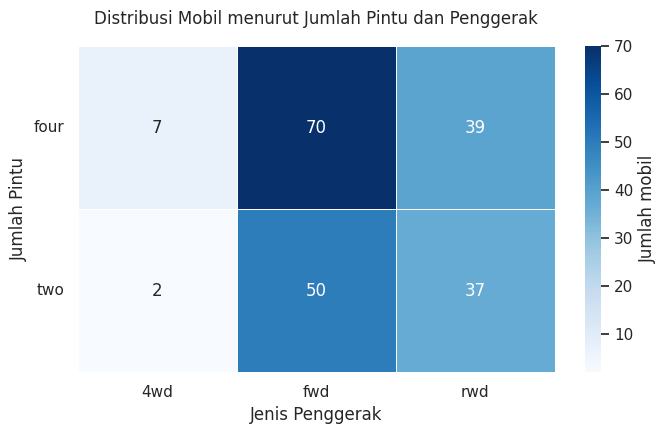

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot_distribution, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "Jumlah mobil"}, ax=ax)
ax.set_title("Distribusi Mobil menurut Jumlah Pintu dan Penggerak", pad=16)
ax.set_xlabel("Jenis Penggerak")
ax.set_ylabel("Jumlah Pintu")
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
save_figure(fig, "06_heatmap_distribusi.png")


Kombinasi terbanyak adalah mobil empat pintu dengan penggerak depan (`fwd`), sebanyak 70 mobil.


# 4. Kesimpulan


In [17]:
most_common = pivot_distribution.stack().idxmax()
largest_count = int(pivot_distribution.loc[most_common[0], most_common[1]])
price_before_count = int(outlier_summary.loc["price", "outlier_sebelum"])
price_after_count = int(outlier_summary.loc["price", "outlier_sesudah"])
door_label = {"four": "empat", "two": "dua"}[most_common[0]]

display(Markdown(
    f"Data tetap berjumlah {len(df)} baris dan {df.shape[1]} kolom. "
    f"Sebanyak {int(missing_before.sum())} nilai kosong sudah terisi. "
    f"Clamping membatasi {price_before_count} outlier harga tanpa menghapus baris. "
    f"Mobil {door_label} pintu dengan penggerak `{most_common[1]}` paling banyak "
    f"dalam sampel: {largest_count} mobil ({largest_count / len(df) * 100:.2f}%). "
    "Rata-rata harga dan horsepower pada pivot memakai data setelah clamping."
))


Data tetap berjumlah 205 baris dan 26 kolom. Sebanyak 59 nilai kosong sudah terisi. Clamping membatasi 14 outlier harga tanpa menghapus baris. Mobil empat pintu dengan penggerak `fwd` paling banyak dalam sampel: 70 mobil (34.15%). Rata-rata harga dan horsepower pada pivot memakai data setelah clamping.

# 5. Simpan hasil


In [18]:
missing_summary.to_csv(TABLE_DIR / "missing_value.csv", index_label="kolom")
imputation_summary.to_csv(TABLE_DIR / "nilai_imputasi.csv", index=False)
outlier_summary.to_csv(TABLE_DIR / "outlier_iqr.csv")
outliers[["make", "body-style", "price"]].to_csv(
    TABLE_DIR / "outlier_harga_sebelum.csv", index_label="baris_asli")
pivot_price.to_csv(TABLE_DIR / "pivot_harga.csv")
pivot_hp.to_csv(TABLE_DIR / "pivot_horsepower.csv")
pivot_distribution.to_csv(TABLE_DIR / "pivot_distribusi.csv")
df_imputed.to_csv(OUTPUT_DIR / "Automobile_setelah_imputasi.csv", index=False)
df.to_csv(OUTPUT_DIR / "Automobile_setelah_clamping.csv", index=False)

ringkasan_hasil = {
    "baris_awal": len(df_raw), "baris_akhir": len(df), "jumlah_kolom": df.shape[1],
    "missing_sebelum": int(missing_before.sum()), "missing_sesudah": int(missing_after.sum()),
    "kolom_numerik_diperiksa": len(numeric_cols),
    "outlier_harga_sebelum": price_before_count, "outlier_harga_sesudah": price_after_count,
    "outlier_sesudah_semua_kolom_dengan_batas_semula": int(outlier_summary["outlier_sesudah"].sum()),
    "total_pivot_distribusi": int(pivot_distribution.to_numpy().sum()),
    "grafik_tersimpan": len(list(FIGURE_DIR.glob("*.png"))),
}
assert ringkasan_hasil["baris_akhir"] == 205
assert ringkasan_hasil["missing_sesudah"] == 0
assert ringkasan_hasil["total_pivot_distribusi"] == 205
assert ringkasan_hasil["grafik_tersimpan"] == 7
(OUTPUT_DIR / "ringkasan_hasil.json").write_text(
    json.dumps(ringkasan_hasil, indent=2), encoding="utf-8")
print("Tabel dan grafik tersimpan di folder hasil.")


Tabel dan grafik tersimpan di folder hasil.
